In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
import os

BASE_DIR = os.path.abspath("..")

raw_path = os.path.join(BASE_DIR, "data", "raw")

print(raw_path)

c:\Users\hp\OneDrive\Documents\Bluestock projects\Bluestock_MF_Analytics\data\raw


In [3]:
fund_master = pd.read_csv(os.path.join(raw_path,"01_fund_master.csv"))
nav_history = pd.read_csv(os.path.join(raw_path,"02_nav_history.csv"))
aum = pd.read_csv(os.path.join(raw_path,"03_aum_by_fund_house.csv"))
sip = pd.read_csv(os.path.join(raw_path,"04_monthly_sip_inflows.csv"))
category = pd.read_csv(os.path.join(raw_path,"05_category_inflows.csv"))
folio = pd.read_csv(os.path.join(raw_path,"06_industry_folio_count.csv"))
performance = pd.read_csv(os.path.join(raw_path,"07_scheme_performance.csv"))
transactions = pd.read_csv(os.path.join(raw_path,"08_investor_transactions.csv"))
portfolio = pd.read_csv(os.path.join(raw_path,"09_portfolio_holdings.csv"))
benchmark = pd.read_csv(os.path.join(raw_path,"10_benchmark_indices.csv"))

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [4]:
datasets = {
    "Fund Master": fund_master,
    "NAV History": nav_history,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Transactions": transactions,
    "Portfolio": portfolio,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print("="*60)
    print(name)
    print(df.head())
    print(df.shape)

Fund Master
   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2   Equity    Small Cap  Regular  2009-09-09       BSE 250 SmallCap TRI   
3   Equity    Small Cap   Direct  2013-01-01       BSE 250 SmallCap TRI   
4     Debt         Gilt  Regular  2000-12-30  CRISIL Dynamic Gilt Index   

   expense_ratio_pct  exit_load_pct  min_sip_amount  min_lumps

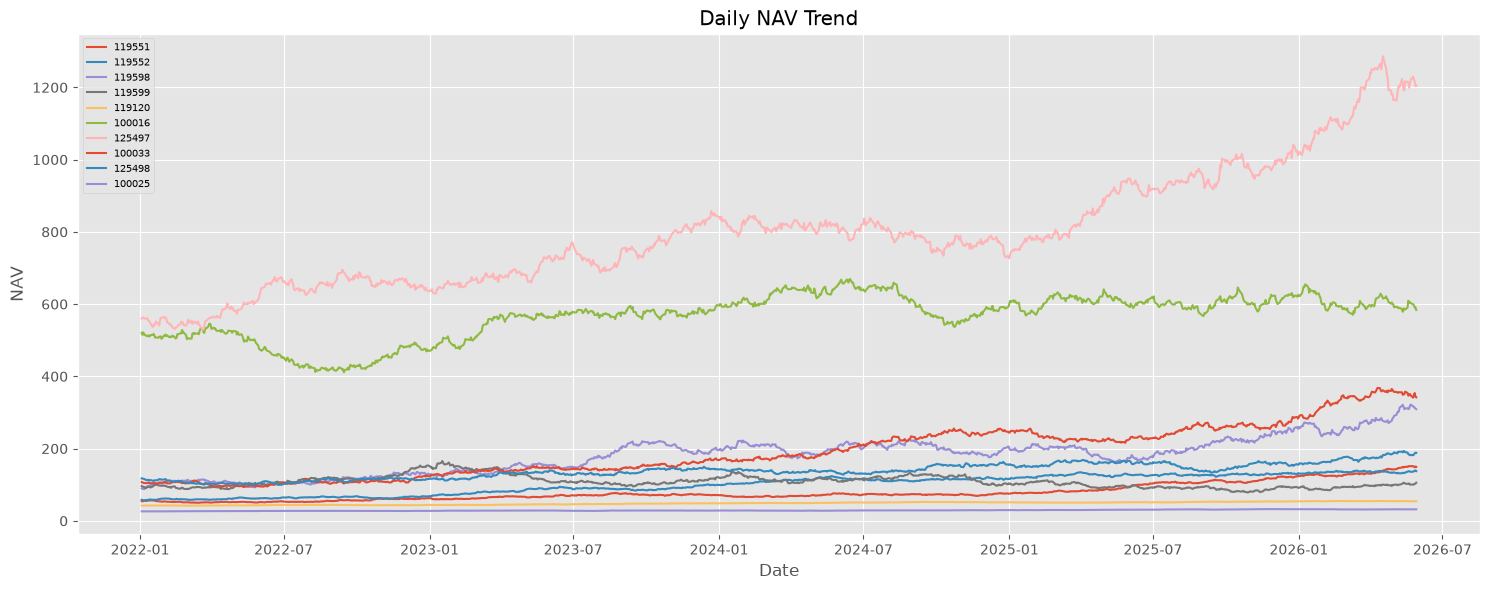

In [5]:
# NAV Trend Analysis

nav_history["date"] = pd.to_datetime(nav_history["date"])

plt.figure(figsize=(15,6))

for code in nav_history["amfi_code"].unique()[:10]:
    temp = nav_history[nav_history["amfi_code"] == code]
    plt.plot(temp["date"], temp["nav"], label=str(code))

plt.title("Daily NAV Trend")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend(loc="upper left", fontsize=7)
plt.grid(True)

plt.tight_layout()
plt.savefig("../reports/nav_trend_all_funds.png")
plt.show()

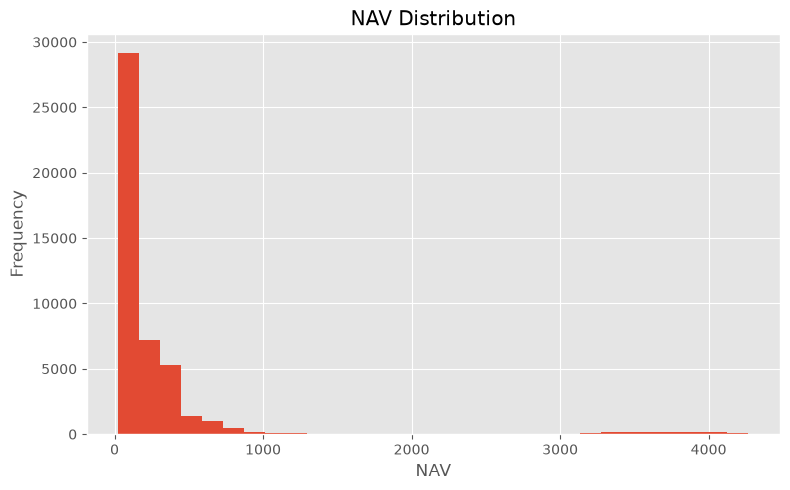

In [6]:
plt.figure(figsize=(8,5))

plt.hist(nav_history["nav"], bins=30)

plt.title("NAV Distribution")
plt.xlabel("NAV")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("../reports/nav_distribution.png")
plt.show()

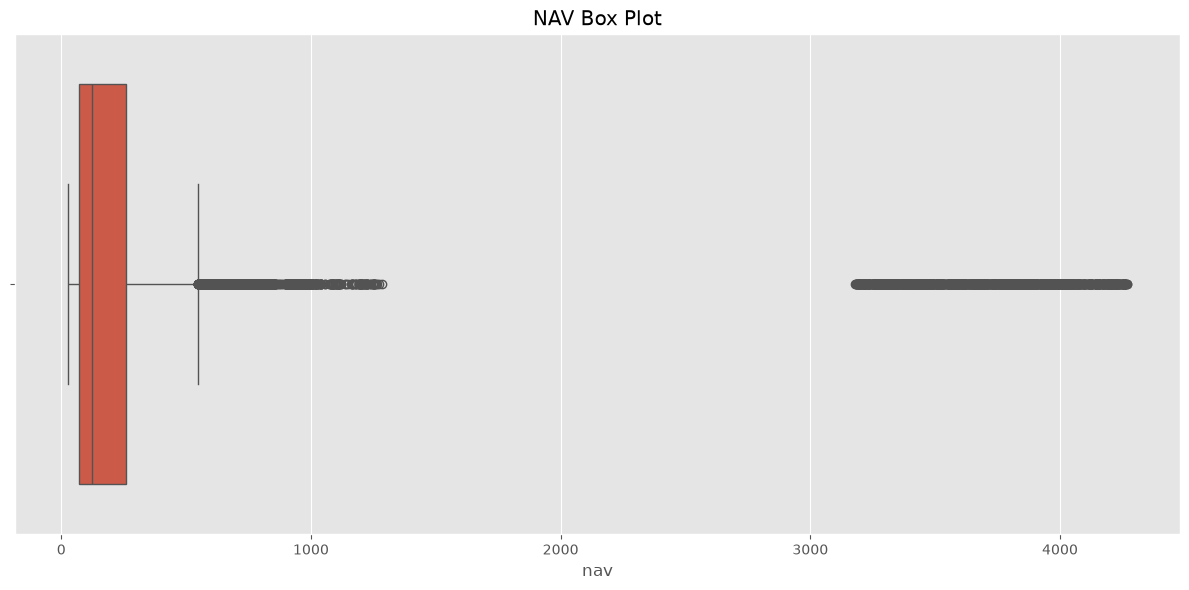

In [7]:
plt.figure(figsize=(12,6))

sns.boxplot(x=nav_history["nav"])

plt.title("NAV Box Plot")

plt.tight_layout()
plt.savefig("../reports/nav_boxplot.png")
plt.show()

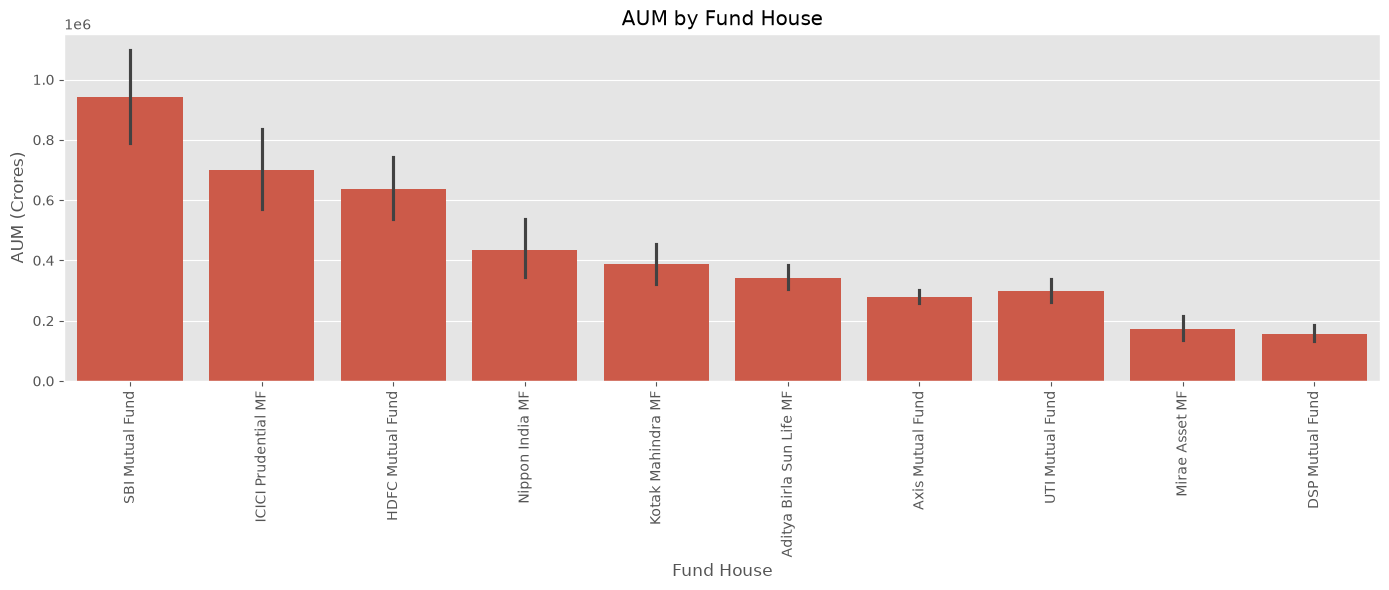

In [10]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_crore"
)

plt.xticks(rotation=90)

plt.title("AUM by Fund House")
plt.xlabel("Fund House")
plt.ylabel("AUM (Crores)")

plt.tight_layout()
plt.savefig("../reports/aum_by_fund_house.png")
plt.show()

In [11]:
print(sip.columns)

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')


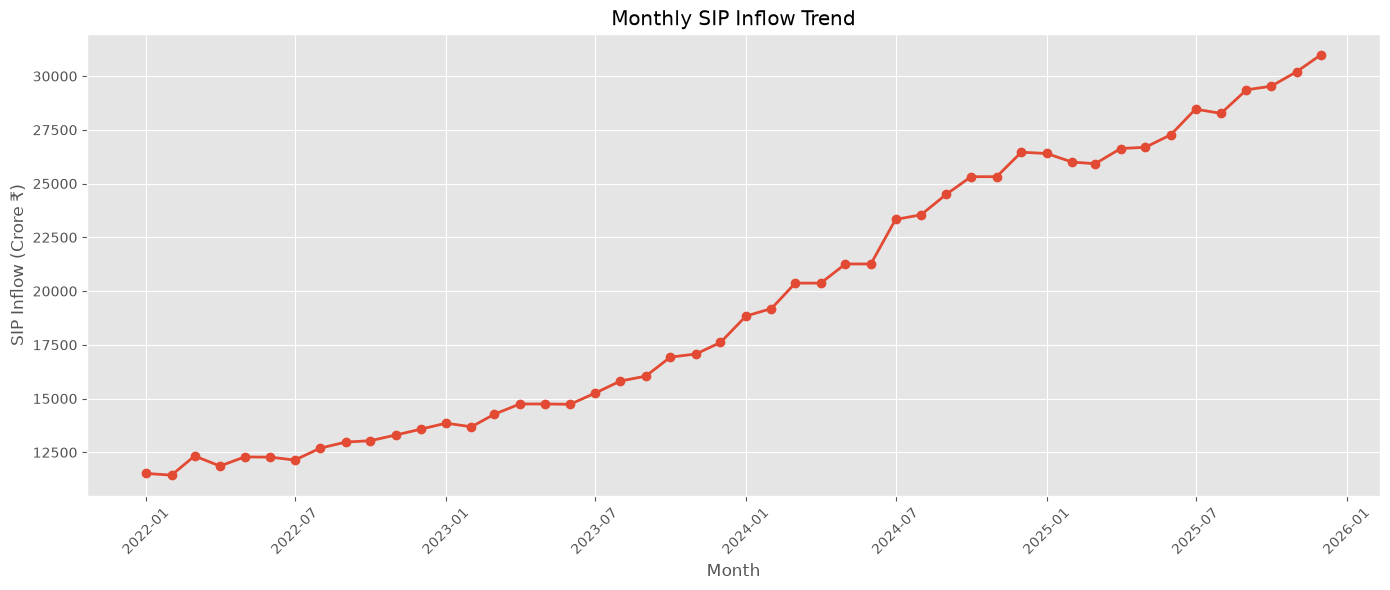

In [12]:
# Monthly SIP Inflow Trend

sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(14,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o",
    linewidth=2
)

plt.title("Monthly SIP Inflow Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore ₹)")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.savefig("../reports/monthly_sip_trend.png")
plt.show()

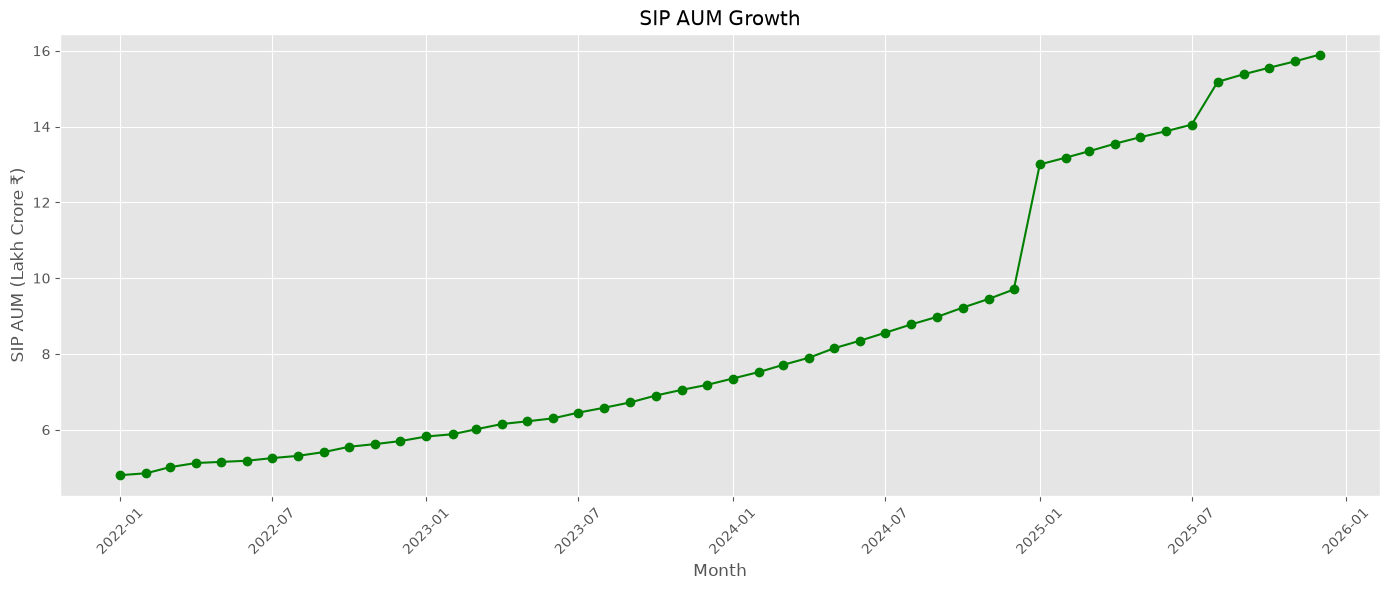

In [13]:
plt.figure(figsize=(14,6))

plt.plot(
    sip["month"],
    sip["sip_aum_lakh_crore"],
    color="green",
    marker="o"
)

plt.title("SIP AUM Growth")
plt.xlabel("Month")
plt.ylabel("SIP AUM (Lakh Crore ₹)")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.savefig("../reports/sip_aum_growth.png")
plt.show()

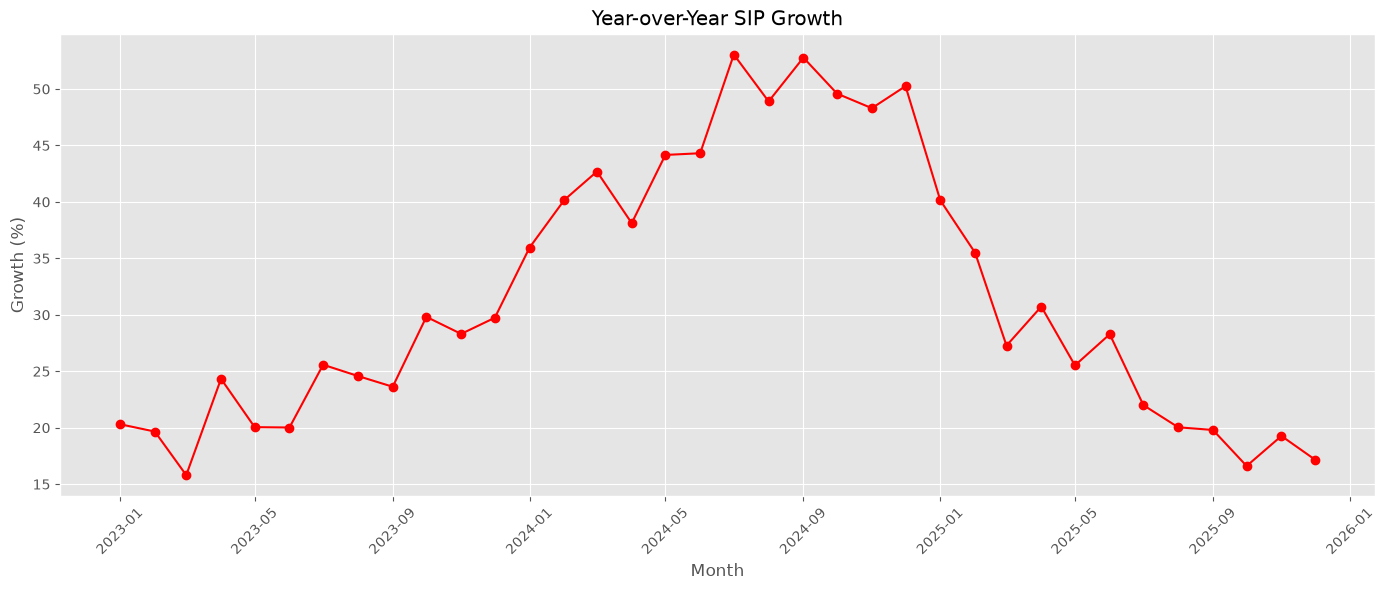

In [14]:
plt.figure(figsize=(14,6))

plt.plot(
    sip["month"],
    sip["yoy_growth_pct"],
    color="red",
    marker="o"
)

plt.title("Year-over-Year SIP Growth")
plt.xlabel("Month")
plt.ylabel("Growth (%)")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.savefig("../reports/yoy_growth.png")
plt.show()

In [15]:
print(category.columns)

Index(['month', 'category', 'net_inflow_crore'], dtype='str')


In [16]:
print(folio.columns)

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')


In [17]:
print(performance.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')


In [18]:
print(transactions.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


In [19]:
print(portfolio.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


In [20]:
print(benchmark.columns)

Index(['date', 'index_name', 'close_value'], dtype='str')


In [21]:
print("CATEGORY")
print(category.columns)

print("\nFOLIO")
print(folio.columns)

print("\nPERFORMANCE")
print(performance.columns)

print("\nTRANSACTIONS")
print(transactions.columns)

print("\nPORTFOLIO")
print(portfolio.columns)

print("\nBENCHMARK")
print(benchmark.columns)

CATEGORY
Index(['month', 'category', 'net_inflow_crore'], dtype='str')

FOLIO
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

PERFORMANCE
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

TRANSACTIONS
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

PORTFOLIO
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtyp

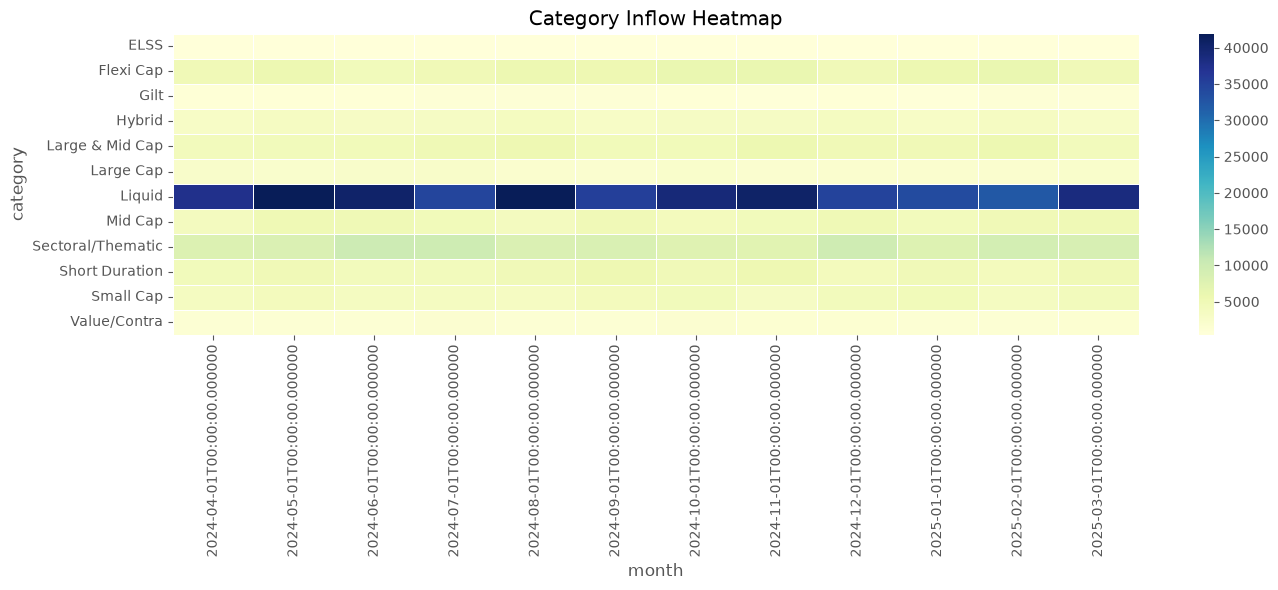

In [22]:
# Category Inflow Heatmap

category["month"] = pd.to_datetime(category["month"])

heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Category Inflow Heatmap")

plt.tight_layout()
plt.savefig("../reports/category_heatmap.png")
plt.show()

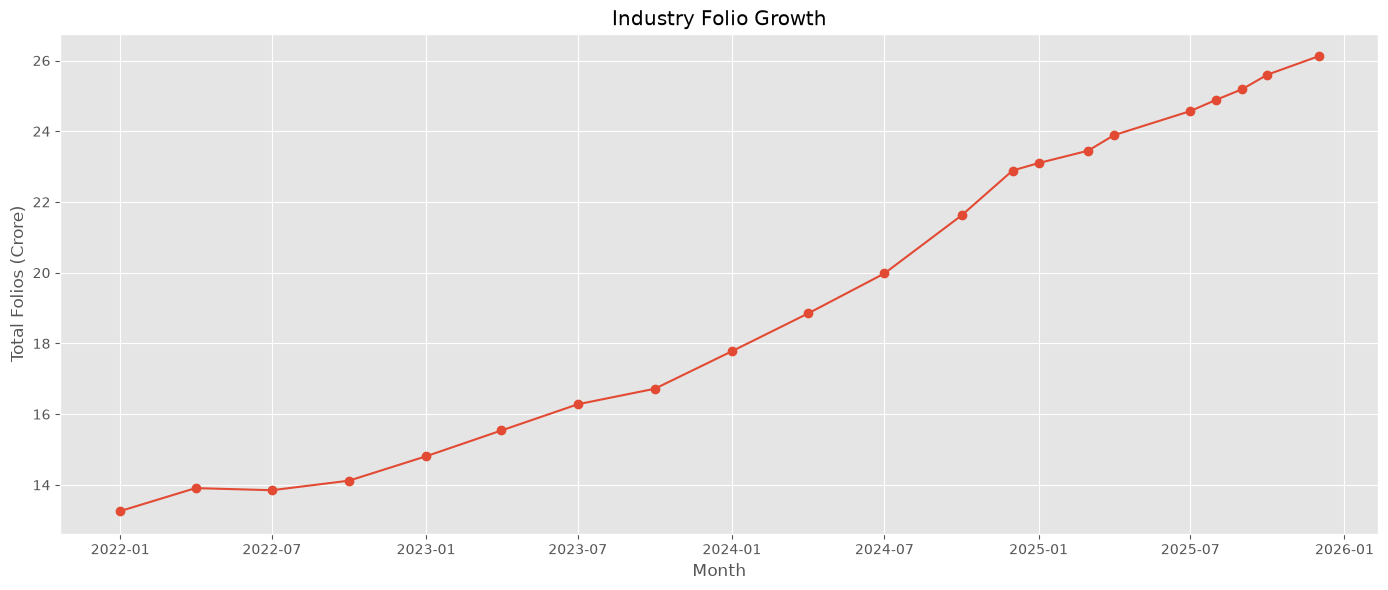

In [23]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Industry Folio Growth")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.tight_layout()
plt.savefig("../reports/folio_growth.png")
plt.show()

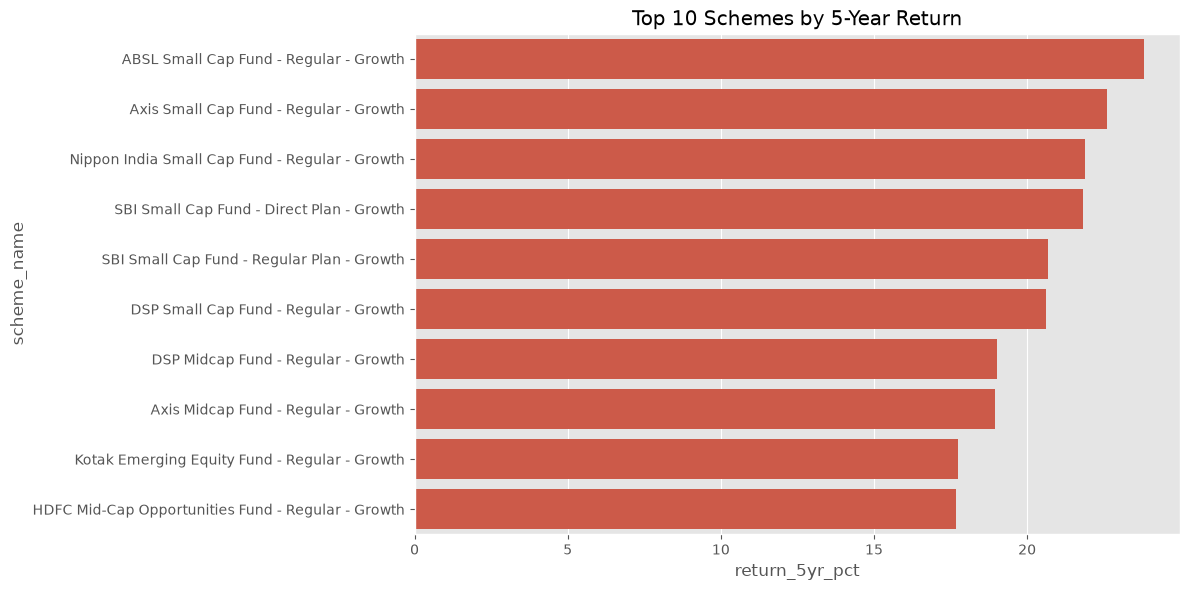

In [24]:
top10 = performance.sort_values(
    "return_5yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="return_5yr_pct",
    y="scheme_name"
)

plt.title("Top 10 Schemes by 5-Year Return")

plt.tight_layout()
plt.savefig("../reports/top10_return5yr.png")
plt.show()

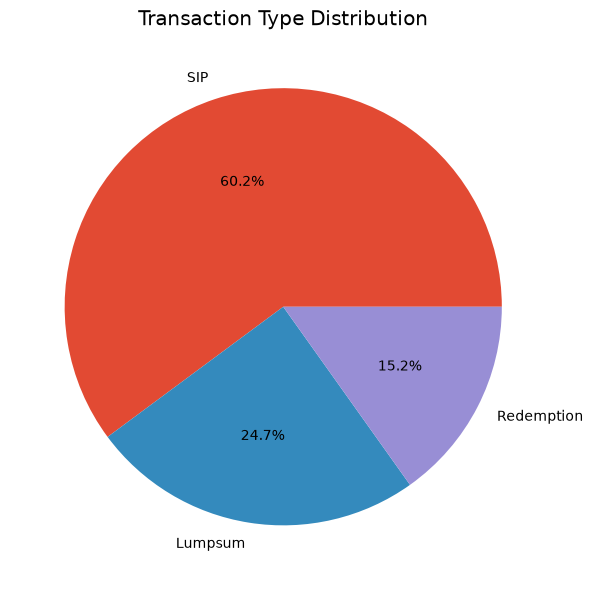

In [25]:
plt.figure(figsize=(8,6))

transactions["transaction_type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Transaction Type Distribution")

plt.tight_layout()
plt.savefig("../reports/transaction_distribution.png")
plt.show()

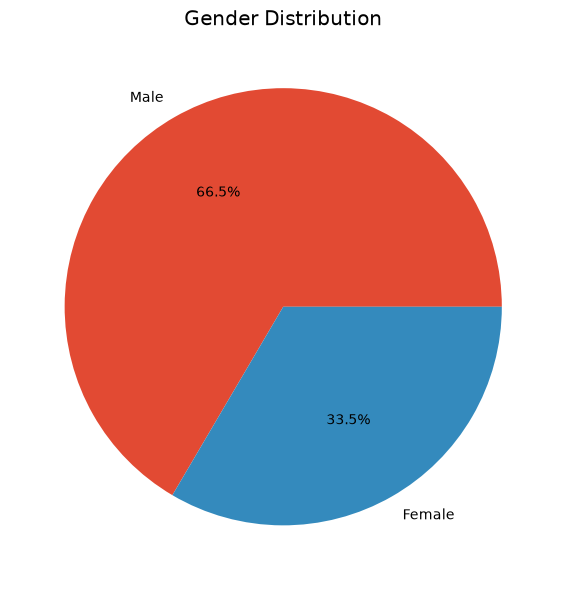

In [26]:
plt.figure(figsize=(8,6))

transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Gender Distribution")

plt.tight_layout()
plt.savefig("../reports/gender_distribution.png")
plt.show()

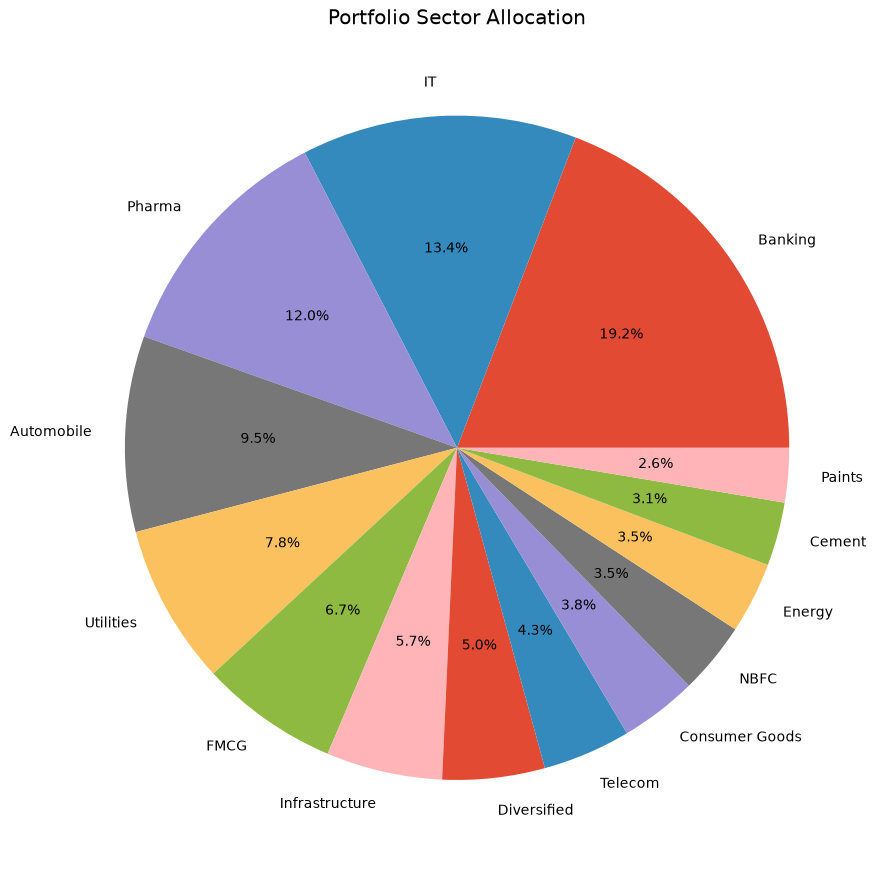

In [27]:
sector = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,9))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%"
)

plt.title("Portfolio Sector Allocation")

plt.tight_layout()
plt.savefig("../reports/sector_allocation.png")
plt.show()

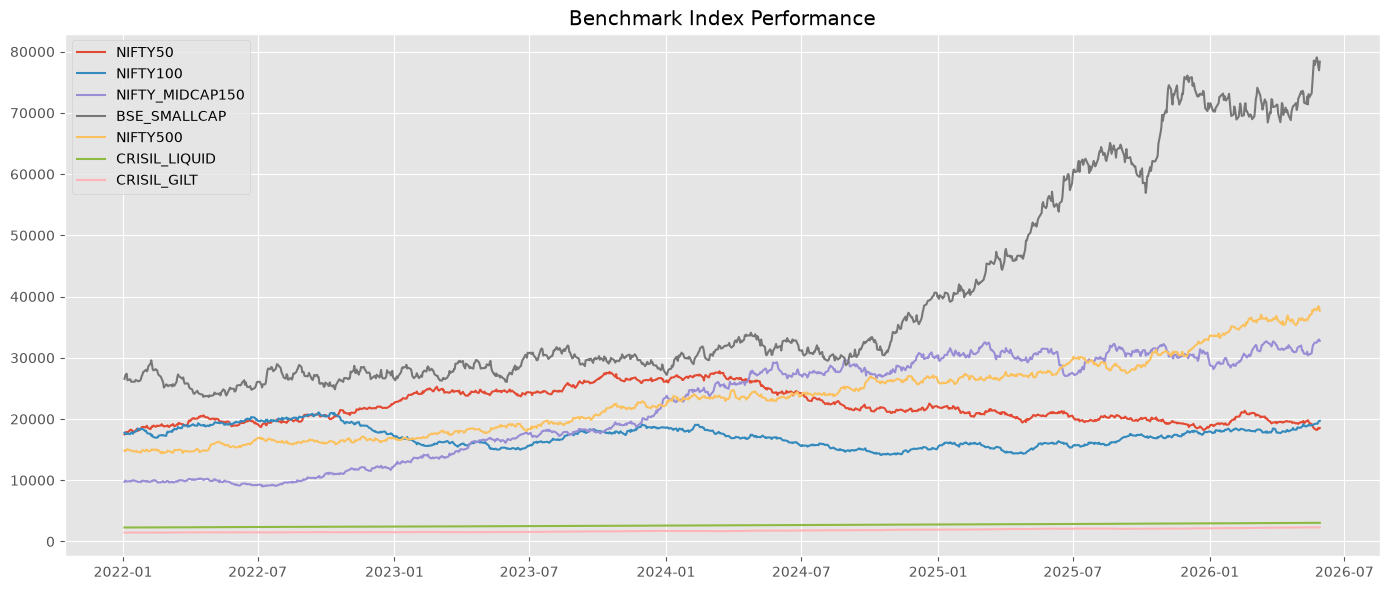

In [28]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

plt.figure(figsize=(14,6))

for idx in benchmark["index_name"].unique():
    temp = benchmark[benchmark["index_name"] == idx]

    plt.plot(
        temp["date"],
        temp["close_value"],
        label=idx
    )

plt.legend()

plt.title("Benchmark Index Performance")

plt.grid(True)

plt.tight_layout()
plt.savefig("../reports/benchmark_trend.png")
plt.show()

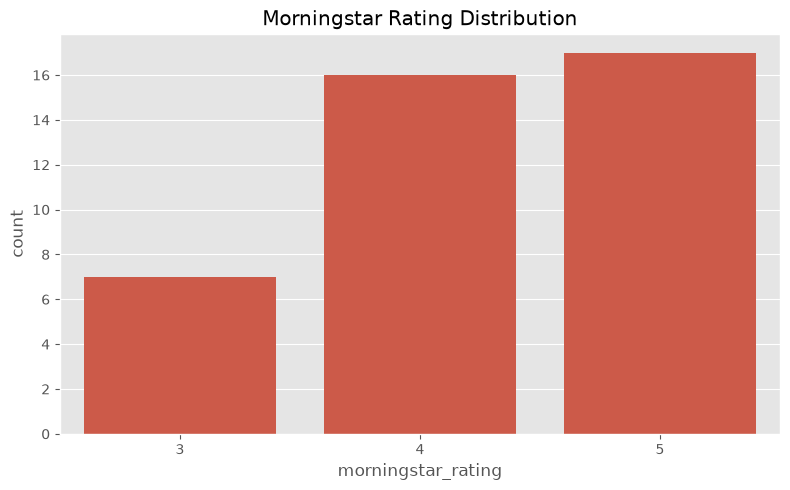

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=performance,
    x="morningstar_rating"
)

plt.title("Morningstar Rating Distribution")

plt.tight_layout()
plt.savefig("../reports/morningstar_rating.png")
plt.show()

# Business Insights

1. SBI Mutual Fund manages one of the highest AUMs among all fund houses.

2. SIP inflows have shown a consistent upward trend, indicating growing retail investor participation.

3. Equity funds contribute significantly to the industry's overall folio count.

4. Large-cap and bluechip funds demonstrate relatively stable NAV growth over time.

5. Several schemes achieved strong 5-year returns, making them attractive long-term investments.

6. The majority of investor transactions are SIP investments rather than lump-sum investments.

7. Portfolio allocations are concentrated in sectors such as Financial Services, IT, and Banking.

8. Benchmark indices have exhibited long-term positive growth despite short-term market corrections.

9. Morningstar ratings indicate that a significant number of schemes are highly rated.

10. Historical NAV trends reveal that long-term investing provides relatively stable wealth creation compared to short-term market fluctuations.

# Conclusion

This exploratory data analysis examined multiple mutual fund datasets, including NAV history, AUM, SIP inflows, investor transactions, benchmark indices, and portfolio holdings.

The analysis identified important investment trends, sector allocations, fund performance, and investor behavior using various statistical summaries and visualizations. These insights provide a strong foundation for further predictive analytics and investment decision-making.